# Figure S1 | What an embedding vector captures

This notebook uses the GISP2 temperature-anomaly record from Alley (2000) [@Alley:2000aa] to show how the embedding dimension ($E$) and delay ($\tau$) determine which past observations enter an embedding vector. The schematic focuses on the target observation at the end of the displayed record.

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from pathlib import Path

from operator import index
import os
import sys
import itertools

from cedarkit.core.project_config import load_config
from cedarkit.utils.plotting import save_figure
from cedarkit.core.data_var import VarObject
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import PathPatch
from matplotlib.path import Path as mplPath


In [18]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])

figures_dir = stem  / "figures" / "FigS1__embedding"
figures_dir.mkdir(exist_ok=True, parents=True)

In [19]:
project_name = 'GISP2Alley00Tanom_Wu18TSI'
proj_dir = stem / 'hol_temp_tsi_ccm' / project_name  #Path(os.getcwd()).resolve().parents[0]
proj_config = load_config(proj_dir / 'proj_config.yaml')

var_id = proj_config.get_dynamic_attr("{var}.var_id", 'col')
new_var_obj = VarObject(proj_config, proj_dir= proj_dir , var_id=var_id)
new_var_obj.get_real()

# Load data

## Data window

The plotted segment is taken from the GISP2 Alley (2000) [@Alley:2000aa] temperature-anomaly series. The final observation is the target (blue); red markers identify the lagged observations selected for its embedding vector.

In [ ]:
# Omit the initial 80 samples, then work with an independent array for this schematic.
raw_ts = new_var_obj.ts[new_var_obj.real_ts_var].values[80:].copy()
t_eval = np.arange(len(raw_ts))

## Embedding parameters

An $E$-dimensional embedding contains $E$ observations separated by $\tau$ time steps. Consequently, its temporal span is $(E-1)\tau$: increasing either parameter reaches farther into the past, while their visual effects on the sampled points differ.

# Embedding Vector Edu

In [21]:
# Compare delays and dimensions whose joint choice controls the embedding's temporal reach.
taus = [2, 4, 6]  # Example tau values (adjust these)
Es = [4, 6, 8, 10, 12]
d_cols_rows = {'tau':taus, 'E':Es}

In [22]:
def get_style(poster_flag):
    if poster_flag:
        params = {
            'font.size': 18, 'axes.titlesize': 16, 'axes.labelsize': 22,
            'xtick.labelsize': 20, 'ytick.labelsize': 20,
            'legend.fontsize': 19, 'figure.titlesize': 18,
            'figure.dpi': 300, 'savefig.dpi': 300
        }
        return params, 16
    else:
        params = {
            'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 16,
            'xtick.labelsize': 14, 'ytick.labelsize': 14,
            'legend.fontsize': 14, 'figure.titlesize': 16,
            'figure.dpi': 300, 'savefig.dpi': 300
        }
        return params, 14

Grid configuration

In [23]:

col_var = 'E'#'tau'
row_var = 'tau'#'E'
# Prepare figure with GridSpec
height_ratios = [6, 2.5,.5]
height_ratios.extend([4 for _ in range(len(d_cols_rows[row_var]))])

Plot bounds

In [24]:
# Use the widest requested embedding window so every panel can share a consistent context.
# Various bounds
segment_max = raw_ts[-max(taus)*max(Es)-2:]
time_segment_max = t_eval[-max(taus)*max(Es)-2:]
right_lim = time_segment_max[-1]
min_time = time_segment_max[-max(taus)*(max(Es)-1)]
max_time = time_segment_max[-1]


In [25]:
def nice_ylims(y, pad=0.12, pad_top=None, pad_bottom=None, robust_pct=None,
               extra_bottom_lastrow=0.10):
    """
    y               : 1D array-like
    pad             : default symmetric fractional padding (of data span)
    pad_top/bottom  : override top/bottom padding (fractions of span)
    robust_pct      : if not None, use [robust_pct, 100-robust_pct] percentiles
    extra_bottom_lastrow : extra padding to add to bottom for last row
    """
    y = np.asarray(y)
    if robust_pct is not None:
        lo, hi = np.nanpercentile(y, [robust_pct, 100-robust_pct])
    else:
        lo, hi = np.nanmin(y), np.nanmax(y)

    if not np.isfinite(lo) or not np.isfinite(hi):
        return (-1, 1)

    if hi == lo:  # flat series: give it some span
        span = max(1.0, abs(hi))  # scale to magnitude if nonzero
        lo -= span * pad
        hi += span * pad
        return (lo, hi)

    span = np.abs(hi - lo)
    top_pad    = pad if pad_top    is None else pad_top
    bottom_pad = pad if pad_bottom is None else pad_bottom

    return (lo - span * bottom_pad, hi + span * top_pad)

def find_ylim_final_subplot(d_cols_rows, col_var, row_var, raw_ts, base_pad=0.12, top_pad=0.15):
    ylims_final_subplot = []
    last_col = len(d_cols_rows[col_var]) - 1
    last_row = len(d_cols_rows[row_var]) - 1

    for j, row_var_val in enumerate(d_cols_rows[row_var]):
        col_var_val = d_cols_rows[col_var][last_col]
        E, tau = (row_var_val, col_var_val) if row_var == 'E' else (col_var_val, row_var_val)

        window = raw_ts[-tau * (E - 1) - 2:]
        bottom_pad = base_pad + (0.13 if j == last_row else 0.03)

        lo, hi = nice_ylims(window, pad=base_pad, pad_top=top_pad, pad_bottom=bottom_pad)
        ylims_final_subplot.append([lo, hi])

    return ylims_final_subplot

# y_bounds = [ax_full.get_yticks()[np.argwhere(ax_full.get_yticks()>ylims_final_subplot[-1][0]).flatten()[0]], ax_full.get_yticks()[np.argwhere(ax_full.get_yticks()<ylims_final_subplot[-1][1]).flatten()[-1]]]
def get_bounded_ticks(_ax, axis, lims=None, ticks=None, buffer=0, rounding_decimals=1):

    get_lim = {
        "x": _ax.get_xlim(),
        "y": _ax.get_ylim(),
        }

    get_ticks = {
        'x': _ax.get_xticks(),
        'y': _ax.get_yticks(),
    }
    existing_lims = get_lim[axis] if lims is None else lims
    existing_ticks = get_ticks[axis] if ticks is None else ticks

    bottom_index = np.argwhere(existing_ticks>min(existing_lims)).flatten().min()#[0]
    top_index = np.argwhere(existing_ticks<max(existing_lims)).flatten().max()#[-1]

    if existing_lims[0]<existing_lims[1]:
        bounds = [existing_ticks[bottom_index], existing_ticks[top_index]]
    else:
        bounds = [existing_ticks[top_index], existing_ticks[bottom_index]]

    return bounds

This figure exists to make the abstract (E, τ) parameters concrete before Fig. S2
shows why you can't just pick a single "best" pair from self-prediction skill alone —
together, the two figures are the paper's case (Methods: *Workflow*) for sweeping 49
(E, τ) combinations per dyad instead of settling on one.


In [26]:
    # Select the E samples ending at the target, with adjacent samples separated by tau steps.
def plot_embedding_subplot(
    fig, subfig_gs,
    tau, E, title, ylabel,
    time_segment_max, segment_max,
    min_time, right_lim, max_time,
    ylims, y_bounds,
    colors, Es, d_cols_rows, col_var, row_var,
    annotation_text_size, col_ind, row_ind
):
    """Draw one (tau, E) embedding panel: the snippet subplot (top, showing
    the raw segment with the tau-spaced embedding points highlighted) and
    the sparkline subplot (bottom, showing those points on the shared time
    axis with a position-indicator patch). Adds the pair into gs[j+top_rows, i].
    """

    # subfig_gs = GridSpec(2,1, figure=subfig, height_ratios=[4, 2], hspace=0.35)

    # Top subplot for the time series segment
    ax_snippet = fig.add_subplot(subfig_gs[0], facecolor='none') # ax
    ax_sparkline = fig.add_subplot(subfig_gs[1], facecolor='none') #ax2

    time_segment = time_segment_max[-tau*(E-1)-2:-1]
    segment = segment_max[-tau*(E-1)-2:-1]
    snippet_time = time_segment[::-tau][::-1]
    snippet_points = segment[::-tau][::-1]
    snippet_xlims = [max([snippet_time[0]-2, min_time]), right_lim]

    sns.lineplot(x=time_segment, y=segment, color='lightblue', ax=ax_snippet, label='Alley, 2000', lw=3)

    estimated_point_label = 'embedding points' if (col_ind == len(d_cols_rows[col_var])-1 and row_ind == 0) else None
    target_point_label = 'target' if (col_ind == len(d_cols_rows[col_var])-1 and row_ind == 0) else None
    estimated_snippet_label = 'estimated snippet' if (col_ind == len(d_cols_rows[col_var])-1 and row_ind == 0) else None

    sns.scatterplot(x=snippet_time, y=snippet_points, color='red', ax=ax_snippet, label=estimated_point_label, zorder=101)
    sns.scatterplot(x=[time_segment_max[-1]], y=[segment_max[-1]], color='steelblue', ax=ax_snippet, label=target_point_label, zorder=100)

    y_offset = 0
    sns.lineplot(x=snippet_time, y=snippet_points-y_offset, color='red', ax=ax_snippet, alpha=.5, label=estimated_snippet_label, zorder=101)
    sns.lineplot(x=snippet_time, y=snippet_points, color='red', ax=ax_sparkline, alpha=.5, label=estimated_snippet_label, zorder=101)

    ax_snippet.set_xlim(snippet_xlims)

    snippet_bounds = y_bounds
    snippet_ticks = [f'{y_bounds[0]:.1f}', f'{y_bounds[1]:.1f}']
    snippet_bounds = [float(val) for val in snippet_ticks]

    ax_snippet.set(ylim=ylims)
    ax_snippet.set(yticks=snippet_bounds, ylabel=ylabel, yticklabels=snippet_ticks)

    # Tick at a stride of the embedding sample points (the red dots), which
    # are exactly tau apart by construction. This keeps every panel's labels
    # evenly spaced, unlike deriving ticks from matplotlib's default locator,
    # while capping the tick count so wider (E, tau) panels don't get crowded.
    max_snippet_ticks = 4
    tick_stride = max(1, int(np.ceil(len(snippet_time) / max_snippet_ticks)))
    snippet_ticks_x = snippet_time[::-tick_stride][::-1]
    ax_snippet.set_xticks(snippet_ticks_x)
    ax_snippet.set_xticklabels([int(max_time - t) for t in snippet_ticks_x])
    ax_snippet.spines[['bottom']].set_bounds([snippet_xlims[0], right_lim])

    ax_snippet.spines[['left']].set_bounds(snippet_bounds)
    # ax_snippet.set_yticks(snippet_bounds)
    ax_snippet.set_yticklabels([f'{snippet_bounds[0]:.1f}', f'{snippet_bounds[1]:.1f}'])
    # ax_snippet.set_ylabel(ylabel)
    label_coord_y = np.mean(snippet_bounds)#/np.abs(ylims[1]-ylims[0])
    ax_snippet.yaxis.set_label_coords(-0.15, label_coord_y, transform=ax_snippet.get_yaxis_transform())
    ax_snippet.spines['left'].set_position(('outward', 3))

    ax_sparkline.spines[['left', 'top']].set_visible(False)
    ax_sparkline.yaxis.tick_right()
    ax_sparkline.set_ylim(ylims)
    ax_sparkline.spines[['right']].set_bounds(snippet_bounds)
    ax_sparkline.set_yticks(snippet_bounds)
    ax_sparkline.set_yticklabels([f'{snippet_bounds[0]:.1f}', f'{snippet_bounds[1]:.1f}'])

    ax_sparkline.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))  # Adjust 'nbins' as needed
    ax_sparkline.set_xlim([min_time, right_lim])
    ax2_xticks = ax_sparkline.get_xticks()
    ax2_xticklabels = ax_sparkline.get_xticklabels()

    try:
        filter_index_min = np.argwhere(ax2_xticks < snippet_time[0]).flatten()[-1]+1
    except:
        filter_index_min = 0

    try:
        filter_index_max = np.argwhere(ax2_xticks > max_time).flatten()[0]
    except:
        filter_index_max = -1

    ax2_ticks = ax2_xticks[filter_index_min:]
    ax2_ticklabels = ax2_xticklabels[filter_index_min:]

    if len(ax2_ticks) == 0:
        ax2_ticks = np.array(snippet_time[:1])
        ax2_ticklabels = [int(max_time - snippet_time[0])]

    max_common_ticks = 3
    if len(ax2_ticks) > max_common_ticks:
        common_stride = int(np.ceil(len(ax2_ticks) / max_common_ticks))
        ax2_ticks = ax2_ticks[::-common_stride][::-1]

    ax_sparkline.set_xticks(ax2_ticks)
    ax_sparkline_xtick = [int(max_time-tick) for tick in ax_sparkline.get_xticks()]
    ax_sparkline.set_xticklabels(ax_sparkline_xtick)
    ax_sparkline.spines[['bottom']].set_bounds([snippet_time[0], right_lim])

    if j == 0:
        ax_snippet.set_title(title)#, fontsize=24)
    ax_snippet.set_xlabel('Time (snippet scale)', loc='left', fontsize=annotation_text_size)
    ax_snippet.xaxis.set_label_coords(0, .15)
    ax_sparkline.set_xlabel('Time (common scale)', loc='right', fontsize=annotation_text_size)

    if col_ind !=0:
        ax_snippet.set_ylabel('')
        ax_snippet.spines[['left']].set_visible(False)
        ax_snippet.set_yticklabels([])
        ax_snippet.set_yticks([])

    if row_ind < len(d_cols_rows[row_var])-1:
        ax_sparkline.set_xlabel('')
        ax_snippet.set_xlabel('')

    ax_snippet.spines[['top', 'right']].set_visible(False)
    patch_height = np.abs(ax_sparkline.get_ylim()[1]-ax_sparkline.get_ylim()[0])*.07#-.5 - ax_sparkline.get_ylim()[0]) * 0.1
    patch_width = time_segment_max[-1] - snippet_time[0]
    left_x = snippet_time[0]
    lower_y = ax_sparkline.get_ylim()[0]
    rect = patches.Rectangle((left_x, lower_y),
                             patch_width,
                             patch_height,
                             linewidth=0, edgecolor=None,
                             facecolor=colors[i], alpha=(len(Es)-j)/len(Es), zorder=-1)

    ax_sparkline.add_patch(rect)

    if col_ind != len(d_cols_rows[col_var])-1:
        ax_sparkline.spines[['right']].set_visible(False)
        ax_sparkline.set_yticklabels([])
        ax_sparkline.set_yticks([])
    else:
        ax_sparkline.spines['right'].set_position(('outward', 3))  # Move the spine 10 points outward


    if (col_ind == len(d_cols_rows[col_var])-1 and row_ind == 0):
        ax_snippet.get_legend().remove()
        ax_sparkline.get_legend().remove()
    else:
        ax_snippet.get_legend().remove()

    for _ax in [ax_snippet, ax_sparkline]:
        for artist in _ax.collections:
            artist.set_clip_on(False)

    return ax_snippet, ax_sparkline


In [27]:
# Set seaborn style
sns.set_style("ticks")
colors = sns.color_palette("crest", len(Es))
poster_flag = False
params, annotation_text_size = get_style(poster_flag=poster_flag)
plt.rcParams.update(params)

/var/folders/9h/cx1bp4z95ldcks7z_7lm3h280000gn/T/ipykernel_15622/2902900758.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_full.legend(loc='upper right').remove()
/var/folders/9h/cx1bp4z95ldcks7z_7lm3h280000gn/T/ipykernel_15622/2902900758.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set(xticklabels=[int(max_time-tick) for tick in ax_bar.get_xticks()])
/var/folders/9h/cx1bp4z95ldcks7z_7lm3h280000gn/T/ipykernel_15622/2902900758.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set(yticklabels=bar_labels, yticks=np.arange(len(d_cols_rows[col_var])))


Text(0.25, 1, 'Time windows covered given\ndifferent $\\tau$ and E combinations')

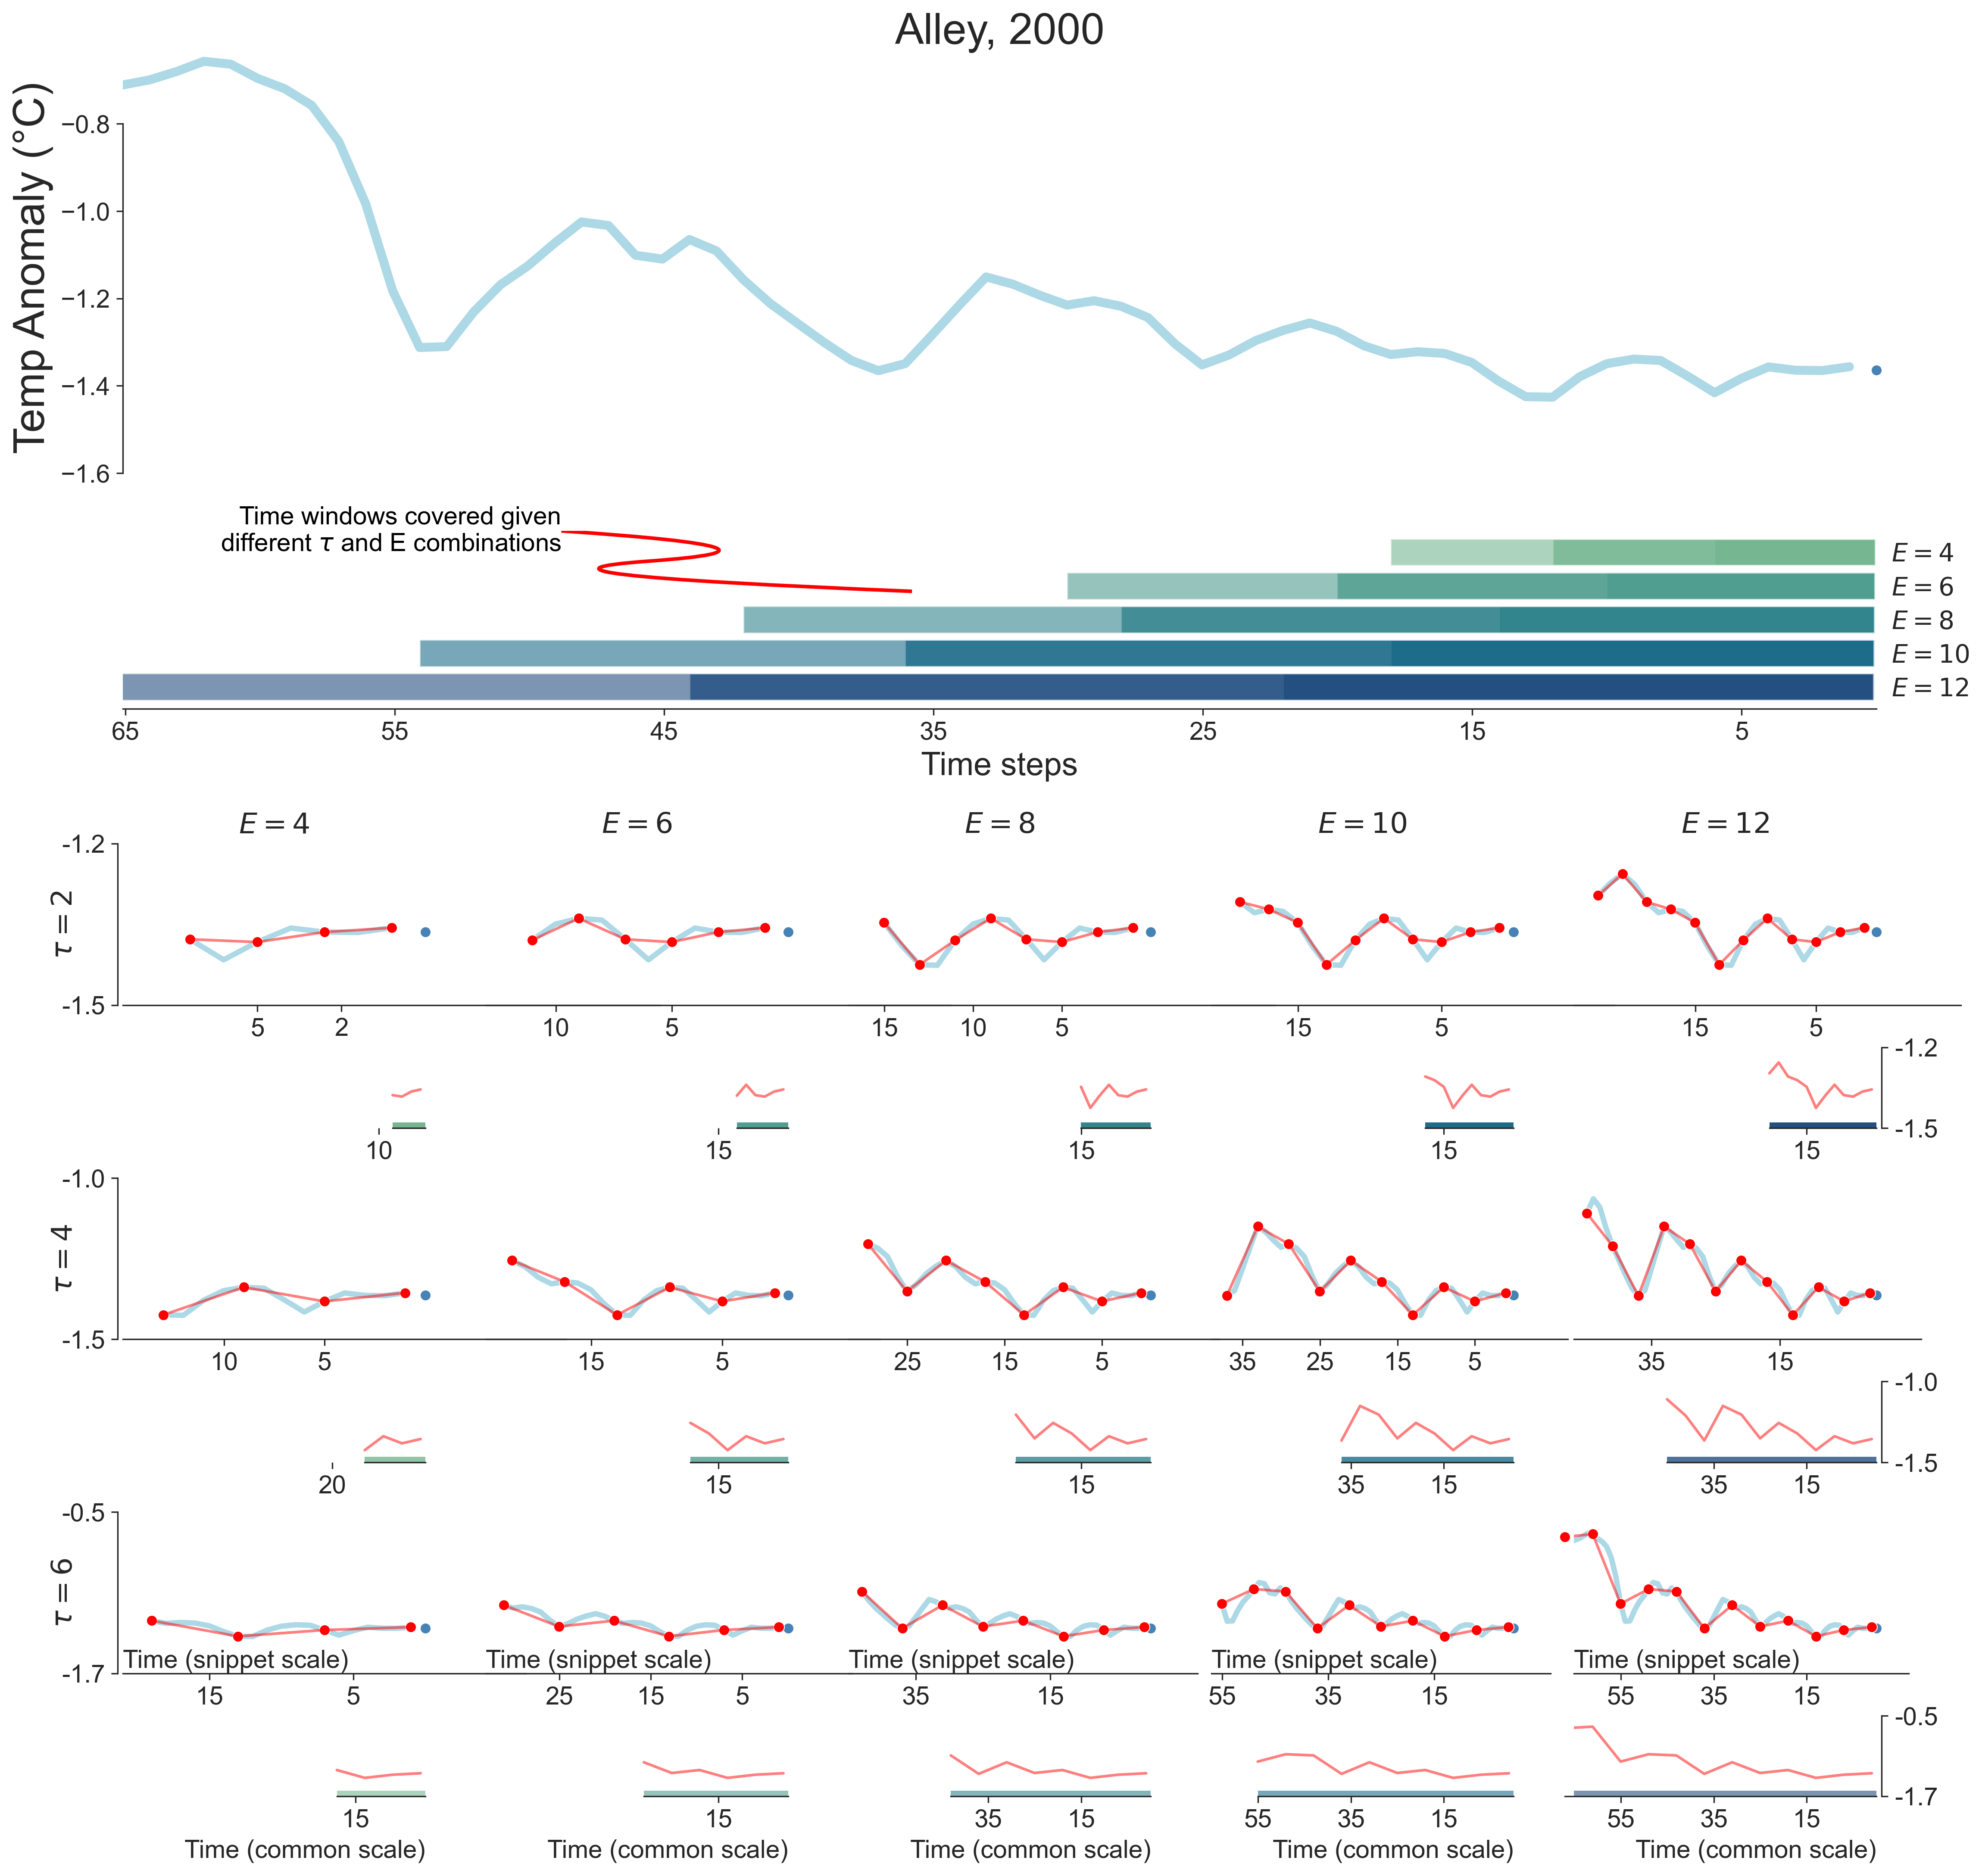

In [28]:
# The embedding window spans (E - 1) * tau time steps from its earliest selected sample to the target.

base_pad = 0.12  # ~12% of span gives visible headroom
top_pad = 0.02
ylims_final_subplot = find_ylim_final_subplot(
    d_cols_rows, col_var, row_var, raw_ts, base_pad=base_pad, top_pad=top_pad
)

fig = plt.figure(figsize=(3.5*len(d_cols_rows[col_var]), 4.5*len(d_cols_rows[row_var]) + 4))
height_ratios = [6, 2.5,.5]
height_ratios.extend([4 for _ in range(len(d_cols_rows[row_var]))])
gs = GridSpec(len(height_ratios), len(d_cols_rows[col_var]), figure=fig, height_ratios=height_ratios, wspace=0.2)

gs_top=[gs[ik, :] for ik in range(2)]#.reshape(2,1)
ax_full = fig.add_subplot(gs_top[0], facecolor='none')
ax_bar = fig.add_subplot(gs_top[1], facecolor='none')


gs_bottom = np.array([[gs[r, c] for c in range(gs.ncols)]
                     for r in range(3, gs.nrows)])

# Plot the full time series in the top row spanning all columns
sns.lineplot(x=time_segment_max[:-1], y=segment_max[:-1], color='lightblue', ax=ax_full, lw=5)
sns.scatterplot(x=[time_segment_max[-1]], y=[segment_max[-1]], color='steelblue', ax=ax_full, zorder=100)

for _ax in [ax_full, ax_bar]:
    for artist in _ax.collections:
        artist.set_clip_on(False)

ax_full_ylims = [segment_max[:-1].min(), segment_max[:-1].max()]
ax_full.set_ylim(ylims_final_subplot[-1])
y_bounds = get_bounded_ticks(ax_full, 'y', lims=None)

ax_full.set_title('Alley, 2000', fontsize=24)
ax_full.legend(loc='upper right').remove()
ax_full.spines[['top', 'right', 'bottom']].set_visible(False)
ax_full.spines[['left']].set_bounds(y_bounds)
ax_full.set_ylabel('Temp Anomaly (°C)',  fontsize=24)
ax_full.set(xticks=[], xlim=[min_time, right_lim])

latex_col_var = col_var.replace("tau", r"\tau")
latex_row_var = row_var.replace("tau", r"\tau")

bar_labels = []
for i, col_var_val in enumerate(d_cols_rows[col_var]):
    title = rf"${latex_col_var}={col_var_val}$"
    bar_labels.append(title)

    for j, row_var_val in enumerate(d_cols_rows[row_var]):

        E, tau = (row_var_val, col_var_val) if row_var=='E' else (col_var_val, row_var_val)

        ylabel = rf"${latex_row_var}={row_var_val}$"

        lim_val = -max(d_cols_rows[col_var])*(row_var_val-1)-2
        _segment = segment_max[lim_val:-1]

        ylims = ylims_final_subplot[j]#[min(min(seg_lims), min(ylims)), max(max(ylims), max(seg_lims))]
        amplitude = np.abs(ylims[1]-ylims[0])
        buffer = amplitude/.9
        y_bounds = [np.round(ylims[0]+buffer, 1), np.round(ylims[1]-buffer, 1)]

        bottom_sg = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_bottom[j, i], height_ratios=[4, 2], hspace=0.35)
        ax_snippet, ax_sparkline = plot_embedding_subplot(
            fig, bottom_sg,
            tau, E, title, ylabel,
            time_segment_max, segment_max,
            min_time, right_lim, max_time,
            ylims, y_bounds,
            colors, Es, d_cols_rows, col_var, row_var,
            annotation_text_size,i, j
        )

        # cumulative bar plot
        embedding_vector_timesteps = (E-1) * tau
        left = time_segment_max[-1] - (time_segment_max[embedding_vector_timesteps] - time_segment_max[0])
        ax_bar.barh(i, embedding_vector_timesteps, left=left, color=colors[i], alpha=(len(d_cols_rows[col_var])-j)/(len(d_cols_rows[col_var])))


max_time = time_segment_max[-1]
ax_bar_xlims = [min_time, right_lim]
ax_bar.set(xlim=ax_bar_xlims)
ax_bar.set(xticklabels=[int(max_time-tick) for tick in ax_bar.get_xticks()])
ax_bar.set_xlabel('Time steps', fontsize=18)
ax_bar.set(yticklabels=bar_labels, yticks=np.arange(len(d_cols_rows[col_var])))

text = 'Time windows covered given\n'+r'different $\tau$ and E combinations'

ax_bar.invert_yaxis()
ax_bar.yaxis.tick_right()
ax_bar.spines[['right']].set_bounds([len(d_cols_rows[col_var])-1, 0])
ax_bar.spines[['right']].set_position(('axes', 1.005))
ax_bar.spines[['top', 'left', 'right']].set_visible(False)
ax_bar.tick_params(axis='y', which='major', length=0)

## Add a label with curved arrow to barplot
# Define points and path codes in axes fraction coordinates
start_point = (0.25, 1)
second_point = (start_point[0]+.15, start_point[1]-.1)
third_point = (second_point[0]-.1, second_point[1]-.07)
fourth_point = (third_point[0]-.1, third_point[1]-.07)
end_point = (fourth_point[0]+.25, fourth_point[1]-.1)
path_data = [
    (mplPath.MOVETO, start_point),      # Start point
    (mplPath.CURVE3, second_point),     # Control point for the first arc
    (mplPath.CURVE3, third_point),      # End point of the first arc
    (mplPath.CURVE3, fourth_point),     # Control point for the second arc
    (mplPath.CURVE3, end_point),      # End point of the second arc
]

# Create custom path from vertices and codes
vertices = [point for _, point in path_data]
codes = [code for code, _ in path_data]
custom_path = mplPath(vertices, codes) # Create the path object

# Apply axes fraction transformation
path_patch = PathPatch(
    custom_path, facecolor='none', edgecolor='red', lw=2,zorder=1000,
    transform=ax_bar.transAxes)  # Transform to axes fraction coordinates)
ax_bar.add_patch(path_patch)

ax_bar.text(
    start_point[0], start_point[1], text, color='k',
    transform=ax_bar.transAxes, ha='right', va='center', fontsize=annotation_text_size) #,fontweight='bold')

# save_figure(fig, figures_dir, stem="FigS1__embedding", dry_run=True)

## Reading the schematic

Columns vary $E$ and rows vary $\tau$. Each upper panel magnifies the selected snippet, whereas the lower panel places the same red points on a common time axis. The horizontal bars summarize the corresponding temporal coverage.